# TensorFlow 2 quickstart for beginners

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.callbacks import TensorBoard
print(TensorBoard)
import datetime

2025-03-25 16:04:39.522715: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742918679.538337    1278 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742918679.542840    1278 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742918679.558744    1278 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1742918679.558774    1278 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1742918679.558778    1278 computation_placer.cc:177] computation placer alr

<class 'keras.src.callbacks.tensorboard.TensorBoard'>


In [2]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

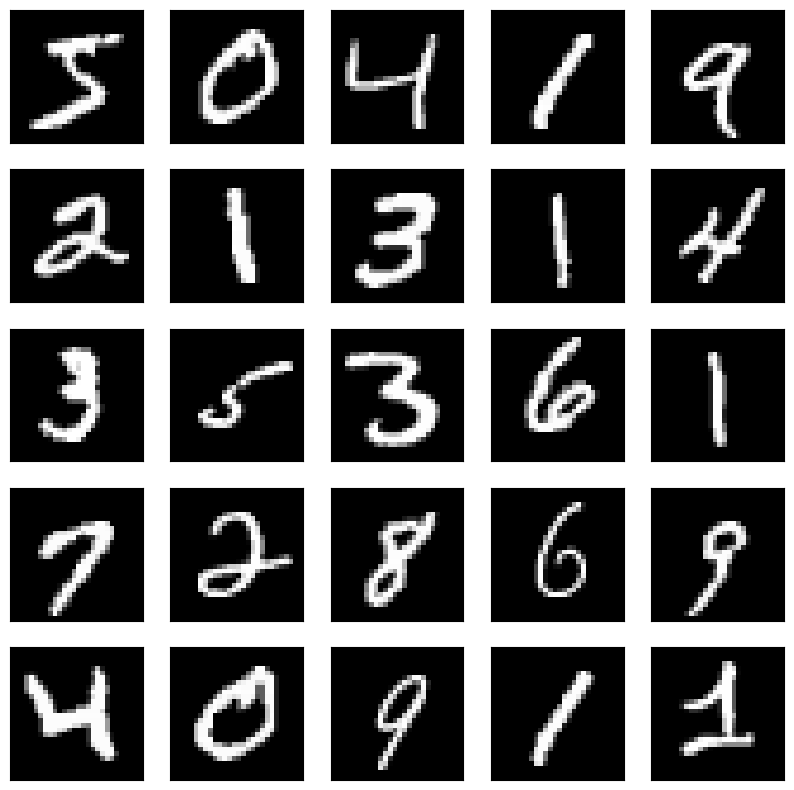

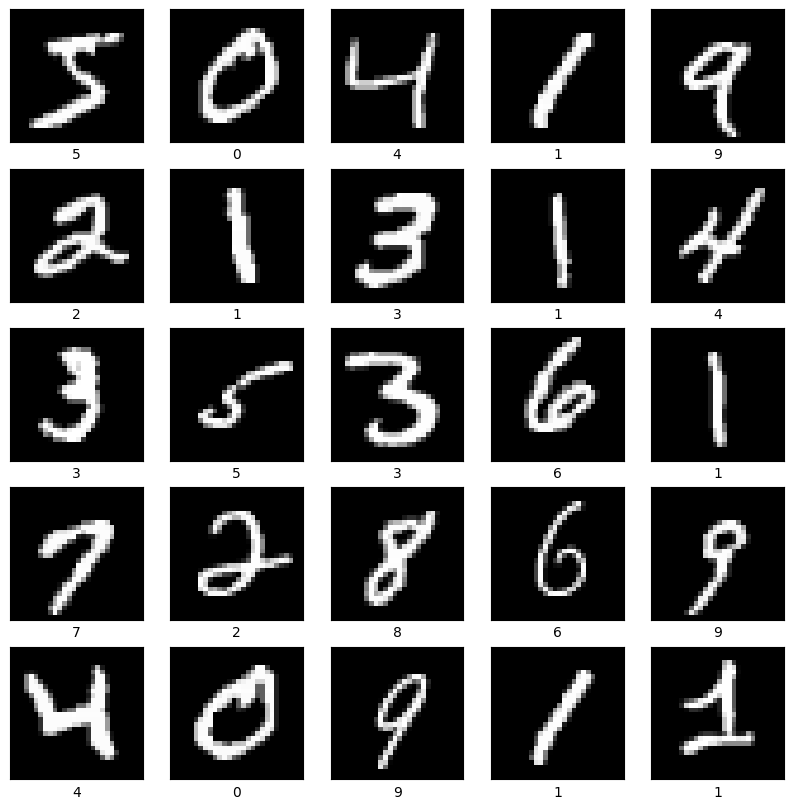

In [3]:
def show_mnist_without_label():
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(x_train[i], cmap="gray")

def show_mnist_with_label():
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(x_train[i], cmap="gray")
        plt.xlabel(y_train[i])

show_mnist_without_label()
show_mnist_with_label()

In [4]:
def create_model(input_shape1, input_shape2, output_shape, activation):
    model = tf.keras.models.Sequential([
      tf.keras.layers.Flatten(input_shape=(input_shape1, input_shape2)),
      tf.keras.layers.Dense(output_shape, activation=activation),
      tf.keras.layers.Dropout(0.4),
      tf.keras.layers.Dense(10)
    ])
    return model

mymodel = create_model(28, 28, 128, 'relu')
mymodel.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1742918684.216522    1278 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
predictions = mymodel(x_train[:1]).numpy()
predictions

array([[-0.21116386, -0.16188207,  0.16410406, -0.7274332 , -0.14127019,
         0.1040405 ,  0.07758163, -0.25380924,  0.2301937 , -0.11217844]],
      dtype=float32)

In [6]:
tf.nn.softmax(predictions).numpy()

array([[0.08697585, 0.09136955, 0.12658302, 0.0519022 , 0.0932724 ,
        0.11920382, 0.11609119, 0.08334471, 0.1352315 , 0.09602571]],
      dtype=float32)

In [7]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [8]:
loss_fn(y_train[:1], predictions).numpy()

np.float32(2.1269205)

In [9]:
mymodel.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

In [19]:
log_dir = "logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,  # Pour voir les distributions des poids
    write_graph=True,  # Pour visualiser l'architecture
    update_freq='epoch'  # Mise à jour à chaque époque
)

In [20]:
mymodel.fit(
    x_train, 
    y_train, 
    epochs=30, 
    validation_split=0.25, 
    verbose=2,
    callbacks=[tensorboard_callback]
)

Epoch 1/30
1407/1407 - 5s - 4ms/step - accuracy: 0.9846 - loss: 0.0455 - val_accuracy: 0.9767 - val_loss: 0.1035
Epoch 2/30
1407/1407 - 5s - 4ms/step - accuracy: 0.9848 - loss: 0.0449 - val_accuracy: 0.9771 - val_loss: 0.1049
Epoch 3/30
1407/1407 - 5s - 4ms/step - accuracy: 0.9856 - loss: 0.0437 - val_accuracy: 0.9766 - val_loss: 0.1087
Epoch 4/30
1407/1407 - 5s - 4ms/step - accuracy: 0.9854 - loss: 0.0423 - val_accuracy: 0.9770 - val_loss: 0.1063
Epoch 5/30
1407/1407 - 5s - 4ms/step - accuracy: 0.9852 - loss: 0.0431 - val_accuracy: 0.9774 - val_loss: 0.1061
Epoch 6/30
1407/1407 - 5s - 4ms/step - accuracy: 0.9850 - loss: 0.0434 - val_accuracy: 0.9761 - val_loss: 0.1082
Epoch 7/30
1407/1407 - 5s - 3ms/step - accuracy: 0.9843 - loss: 0.0464 - val_accuracy: 0.9785 - val_loss: 0.1068
Epoch 8/30
1407/1407 - 5s - 3ms/step - accuracy: 0.9853 - loss: 0.0441 - val_accuracy: 0.9775 - val_loss: 0.1094
Epoch 9/30
1407/1407 - 6s - 4ms/step - accuracy: 0.9858 - loss: 0.0403 - val_accuracy: 0.9778 - 

In [12]:
mymodel.evaluate(x_test,  y_test, verbose=2)

313/313 - 0s - 1ms/step - accuracy: 0.9801 - loss: 0.0877


[0.08774027228355408, 0.9800999760627747]

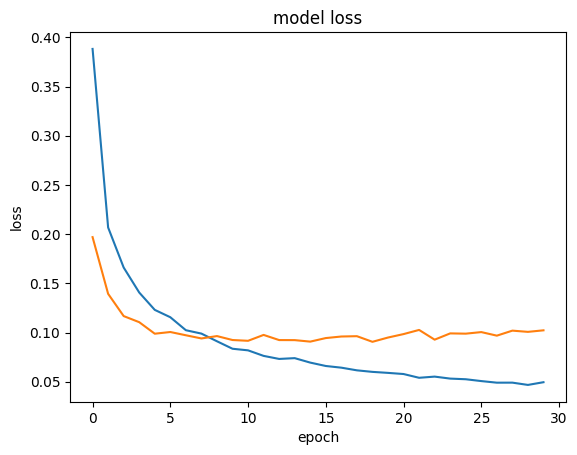

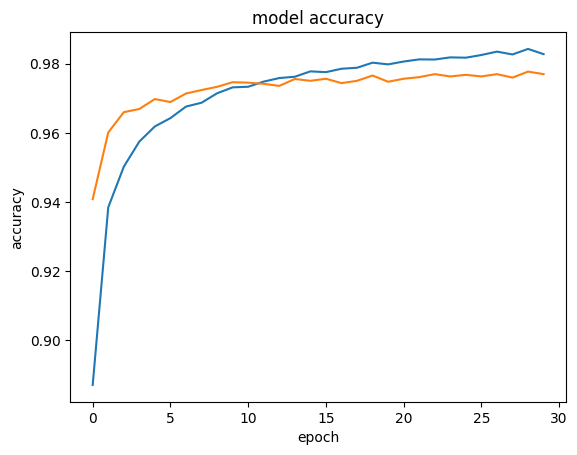

In [13]:
#loss
plt.plot(mymodel.history.history['loss'])
plt.plot(mymodel.history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

#accuracy
plt.plot(mymodel.history.history['accuracy'])
plt.plot(mymodel.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

In [14]:
print(f"Répertoire actuel : {os.getcwd()}")
os.makedirs('model', exist_ok=True)
mymodel.save(os.path.join('model', 'my_model.keras'))

Répertoire actuel : /tf


In [15]:
print(os.listdir('/tf'))

['01 - beginner - 01 STARTER.ipynb', '01 - beginner - 02 STARTER.ipynb', 'Dockerfile', 'image.png', 'model', 'model.keras', 'model2.keras', 'requirements.txt']


In [16]:
probability_model = tf.keras.Sequential([
  mymodel,
  tf.keras.layers.Softmax()
])

In [17]:
probability_model(x_test[:5])

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[6.8749645e-11, 3.5449573e-17, 6.7984597e-11, 2.5278118e-06,
        1.2037867e-22, 1.4778563e-10, 3.4025267e-24, 9.9999750e-01,
        5.8691710e-12, 4.6000288e-09],
       [1.4132203e-15, 1.0338524e-09, 1.0000000e+00, 2.7004859e-10,
        1.8159837e-28, 6.4828988e-14, 1.9865731e-11, 4.5662999e-23,
        2.6087160e-12, 8.4809990e-31],
       [5.3285650e-11, 9.9991179e-01, 1.8943219e-06, 5.1164690e-08,
        3.0016349e-07, 2.8275977e-09, 8.5195158e-09, 1.8099285e-05,
        6.7927132e-05, 1.7147056e-11],
       [9.9998891e-01, 1.6151236e-17, 1.0961983e-05, 1.0127560e-10,
        1.9127790e-13, 6.7746040e-09, 1.6044376e-07, 2.0286188e-09,
        1.8137195e-14, 4.2484136e-10],
       [5.2407492e-12, 5.6089926e-17, 6.9226797e-10, 2.8212481e-11,
        9.9993062e-01, 2.5271856e-11, 1.4549470e-10, 5.2384291e-07,
        3.3858880e-13, 6.8944129e-05]], dtype=float32)>